# Интерактивный селектор стали и болтов по СП 16.13330.2017

Все кривые строятся по узлам `OBD`, `OACD` или `OACDEF`, возвращаемым
`get_diagram_points`. Каталоги толщин, γc и диаметров болтов берутся
из реализованных таблиц СП 16.


In [1]:
import sys
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, Markdown, clear_output, display

project_dir = Path.cwd()
for p in [project_dir, project_dir.parent, project_dir.parent / "structural_materials"]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from sp16_materials import (
    TABLE_1_GAMMA_C,
    SteelBolt,
    StructuralSteel,
    list_gamma_c_options,
    list_steel_grades,
)

print("Модуль sp16_materials успешно загружен.")


Модуль sp16_materials успешно загружен.


## Интерактивный выбор стали и болтов

На диаграмме стали отображаются все узлы выбранного варианта Б.1.
Для справочной диаграммы болтов отсутствующее значение растяжения
остается пропуском, а не подменяется нулевой несущей способностью.


In [2]:
w_profile_type = widgets.Dropdown(
    options=[
        ("Фасонный прокат, В.5", "shapes"),
        ("Листы и трубы, В.3", "plates"),
        ("Двутавры с параллельными гранями, В.4", "beams_parallel"),
    ],
    value="shapes",
    description="Вид проката:",
    style={"description_width": "150px"},
)
w_steel_grade = widgets.Dropdown(
    options=list_steel_grades("shapes"),
    value="С255",
    description="Марка стали:",
    style={"description_width": "150px"},
)
w_thickness = widgets.BoundedFloatText(
    value=12.0,
    min=0.1,
    max=160.0,
    description="Толщина t, мм:",
    style={"description_width": "150px"},
)
w_stat_control = widgets.Checkbox(
    value=True,
    description="Статистический контроль (γm = 1.025)",
    indent=False,
)
# This is the complete Table 1 catalog; there is no hand-entered γc.
w_gamma_c = widgets.Dropdown(
    options=list_gamma_c_options(),
    value=TABLE_1_GAMMA_C["обычные условия"],
    description="γc, таблица 1:",
    style={"description_width": "150px"},
)
w_diagram_model = widgets.Dropdown(
    options=[
        ("OBD", "OBD"),
        ("OACD", "OACD"),
        ("OACDEF", "OACDEF"),
    ],
    value="OACDEF",
    description="Вариант Б.1:",
    style={"description_width": "150px"},
)
w_bolt_grade = widgets.Dropdown(
    options=["5.6", "5.8", "8.8", "10.9", "12.9"],
    value="8.8",
    description="Класс болта:",
    style={"description_width": "150px"},
)
bolt_diameters = [16, 18, 20, 22, 24, 27, 30, 36, 42, 48]
w_bolt_diameter = widgets.Dropdown(
    options=bolt_diameters,
    value=20,
    description="Диаметр, мм:",
    style={"description_width": "150px"},
)
w_special_support = widgets.Checkbox(
    value=False,
    description="ВЛ/ОРУ для диаметров из скобок таблицы Г.9",
    indent=False,
)
w_bolt_gamma_b = widgets.FloatSlider(
    value=1.0, min=0.1, max=1.0, step=0.01,
    description="γb болтов:", style={"description_width": "150px"},
)
out_panel = widgets.Output()


def _set_limits(axis, eps):
    low, high = float(np.min(eps)), float(np.max(eps))
    span = max(high - low, 1e-6)
    axis.set_xlim(low - 0.08 * span, high + 0.08 * span)


def _plot_named_points(axis, points, offsets=None):
    offsets = offsets or {}
    for index, (label, (epsilon, sigma)) in enumerate(points.items()):
        x_value = epsilon * 1000.0
        axis.scatter([x_value], [sigma], color="#d62728", s=28, zorder=5)
        axis.annotate(
            label,
            xy=(x_value, sigma),
            xytext=offsets.get(label, (6, 8 if index % 2 == 0 else -16)),
            textcoords="offset points",
            fontsize=8,
            color="#d62728",
            arrowprops={"arrowstyle": "-", "color": "#d62728", "lw": 0.8},
        )


def _plot_steel_curve(axis, eps, sig, points, title):
    x_values = eps * 1000.0
    axis.plot(x_values, sig, color="#1f77b4", lw=2.3)
    label_offsets = {
        "O": (8, 8),
        "A": (10, -22),
        "B": (10, 10),
        "C": (10, -22),
        "D": (10, 10),
        "E": (8, 10),
        "F": (8, -20),
    }
    _plot_named_points(axis, points, label_offsets)
    axis.set_title(title)
    axis.set_xlabel("ε, ‰")
    axis.set_ylabel("σ, МПа")
    axis.grid(True, linestyle=":", alpha=0.6)
    axis.axhline(0.0, color="black", lw=0.7, alpha=0.5)
    axis.axvline(0.0, color="black", lw=0.7, alpha=0.5)
    _set_limits(axis, x_values)

    # The full B.1 range includes fracture strains of tens of
    # percent, which visually compresses O-A-C-D at the origin.
    # Keep the normative full curve and add a zoom of the node
    # region so the selected variant remains readable.
    focus_labels = {"O", "A", "B", "C", "D"}
    focus_points = {
        label: value for label, value in points.items()
        if label in focus_labels
    }
    if len(focus_points) > 1:
        focus_x = max(abs(epsilon * 1000.0) for epsilon, _ in focus_points.values())
        focus_y = max(abs(sigma) for _, sigma in focus_points.values())
        inset = axis.inset_axes([0.05, 0.51, 0.47, 0.43])
        inset.plot(x_values, sig, color="#1f77b4", lw=1.6)
        _plot_named_points(inset, focus_points, label_offsets)
        inset.set_xlim(-max(2.5, 1.25 * focus_x), max(2.5, 1.25 * focus_x))
        inset.set_ylim(-max(20.0, 1.20 * focus_y), max(20.0, 1.20 * focus_y))
        inset.grid(True, linestyle=":", alpha=0.55)
        inset.axhline(0.0, color="black", lw=0.6, alpha=0.5)
        inset.axvline(0.0, color="black", lw=0.6, alpha=0.5)
        inset.set_title("Узлы O–D", fontsize=8)
        inset.tick_params(labelsize=7)
        axis.indicate_inset_zoom(inset, edgecolor="0.45", linewidth=0.8)


def on_profile_change(change):
    grades = list_steel_grades(w_profile_type.value)
    w_steel_grade.options = grades
    preferred = "С255" if "С255" in grades else grades[0]
    w_steel_grade.value = preferred


def update_view(*_):
    with out_panel:
        clear_output(wait=True)
        try:
            steel = StructuralSteel(
                grade=w_steel_grade.value,
                profile_type=w_profile_type.value,
                thickness=w_thickness.value,
                statistical_control=w_stat_control.value,
                gamma_c=w_gamma_c.value,
            )
            bolt = SteelBolt(
                grade=w_bolt_grade.value,
                diameter=w_bolt_diameter.value,
                gamma_b=w_bolt_gamma_b.value,
                gamma_c=w_gamma_c.value,
                special_support=w_special_support.value,
            )
            eps_arr, sig_arr = steel.get_diagram(
                model=w_diagram_model.value,
                n_points=180,
                signed=True,
            )
            points = steel.get_diagram_points(
                model=w_diagram_model.value,
                signed=True,
            )
        except ValueError as error:
            display(Markdown(f"**Параметры требуют уточнения:** `{error}`"))
            return

        if w_profile_type.value == "beams_parallel" and w_thickness.value > 100.0:
            display(Markdown(
                "*Для В.4 выбрана открытая нормативная область толщин `t > 100 мм`.*"
            ))

        fig, (ax_steel, ax_bolts) = plt.subplots(
            1, 2, figsize=(14.5, 5.2), dpi=110, constrained_layout=True
        )
        _plot_steel_curve(
            ax_steel,
            eps_arr,
            sig_arr,
            points,
            f"Сталь {steel.grade}, {steel.profile_type}, t={steel.thickness:g} мм"
        )

        nbs_values = []
        nbt_values = []
        for diameter in bolt_diameters:
            catalog_bolt = SteelBolt(
                grade=w_bolt_grade.value,
                diameter=diameter,
                gamma_b=w_bolt_gamma_b.value,
                gamma_c=w_gamma_c.value,
                special_support=True,
            )
            nbs_values.append(catalog_bolt.shear_capacity(1))
            tension = catalog_bolt.tension_capacity()
            nbt_values.append(np.nan if tension is None else tension)
        x_values = np.arange(len(bolt_diameters))
        width = 0.38
        ax_bolts.bar(
            x_values - width / 2, nbs_values, width,
            label="Срез Nbs (1 пл.)", color="#ff7f0e", alpha=0.85,
        )
        ax_bolts.bar(
            x_values + width / 2, nbt_values, width,
            label="Растяжение Nbt", color="#2ca02c", alpha=0.85,
        )
        ax_bolts.set_xticks(x_values)
        ax_bolts.set_xticklabels([f"М{diameter}" for diameter in bolt_diameters])
        ax_bolts.set_title(f"Болты класса {w_bolt_grade.value}")
        ax_bolts.set_xlabel("Диаметр по таблице Г.9")
        ax_bolts.set_ylabel("Несущая способность, кН")
        ax_bolts.grid(True, linestyle=":", alpha=0.6, axis="y")
        ax_bolts.legend(loc="upper left", fontsize=9)
        plt.show()

        display(HTML(steel.to_html()))
        display(HTML(bolt.to_html()))


w_profile_type.observe(on_profile_change, names="value")
controls = [
    w_profile_type, w_steel_grade, w_thickness, w_stat_control,
    w_gamma_c, w_diagram_model, w_bolt_grade, w_bolt_diameter,
    w_special_support, w_bolt_gamma_b,
]
for widget in controls:
    widget.observe(update_view, names="value")

steel_box = widgets.VBox(
    [
        widgets.HTML("<b>Параметры прокатной стали</b>"),
        w_profile_type, w_steel_grade, w_thickness,
        w_stat_control, w_gamma_c, w_diagram_model,
    ],
    layout=widgets.Layout(border="1px solid #ddd", padding="10px"),
)
bolt_box = widgets.VBox(
    [
        widgets.HTML("<b>Параметры болтового соединения</b>"),
        w_bolt_grade, w_bolt_diameter, w_special_support, w_bolt_gamma_b,
    ],
    layout=widgets.Layout(border="1px solid #ddd", padding="10px"),
)
display(widgets.HBox([steel_box, bolt_box]))
display(out_panel)
update_view()


Output()

## Пример прямого использования


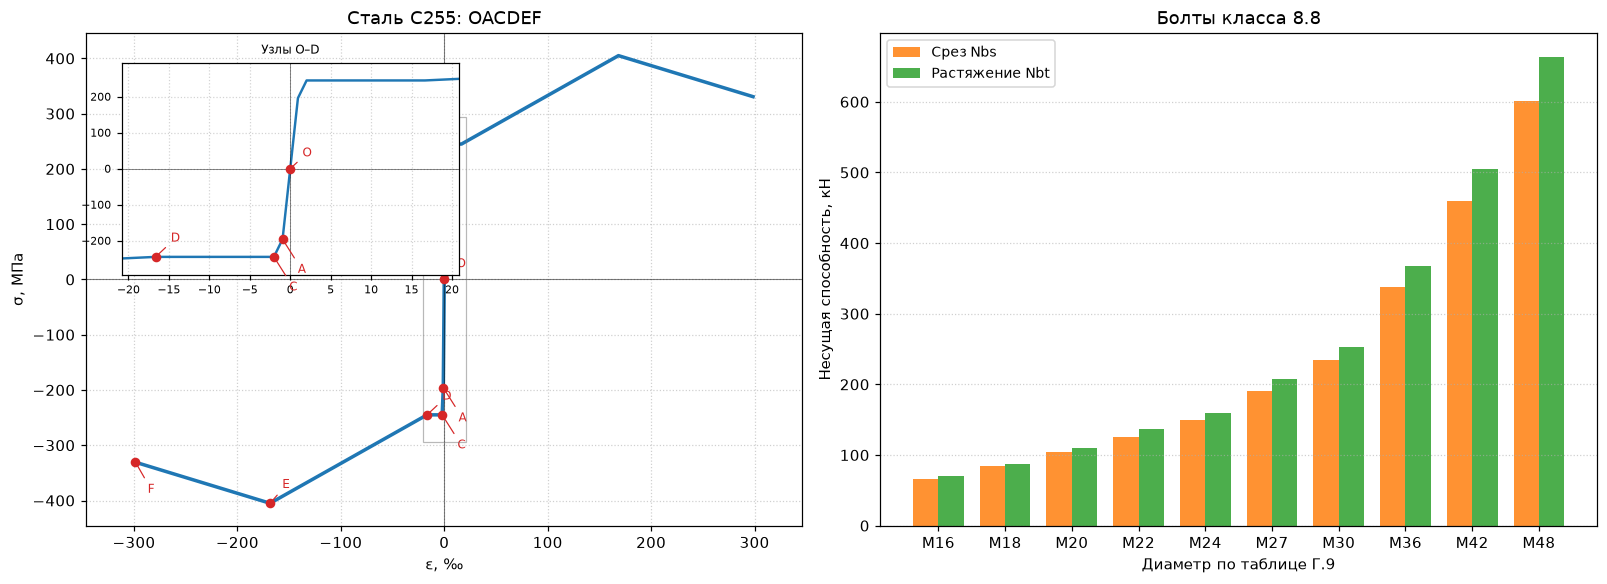

Параметр,Обозначение,Значение,Ед. изм.
Расчетное сопротивление растяжению/сжатию/изгибу,Ry,240.0,МПа
Расчетное сопротивление по пределу прочности,Ru,360.0,МПа
Расчетное сопротивление сдвигу (0.58 Ry),Rs,139.2,МПа
Расчетное сопротивление смятию торцевой поверхности,Rp,361.0,МПа
Расчетное сопротивление смятию в шарнирах (0.5 Ry),Rlp,180.0,МПа
Нормативный предел текучести,Ryn,245.0,МПа
Нормативное временное сопротивление,Run,370.0,МПа
Модуль упругости,E,"206,000",МПа
Модуль сдвига,G,"79,000",МПа
Деформация предела текучести,εy,0.001165,-


Параметр,Обозначение,Значение,Ед. изм.
Расчетное сопротивление срезу,Rbs,332.0,МПа
Расчетное сопротивление растяжению,Rbt,451.0,МПа
Площадь стержня брутто,A,314.0,мм²
Площадь сечения нетто по резьбе,Abn,245.0,мм²
Несущая способность на срез (1 плоскость среза),Nbs,104.248,кН
Несущая способность на растяжение,Nbt,110.495,кН
Коэффициент условий работы соединения,γb,1.0,-
Коэффициент условий работы конструкции,γc,1.0,-


In [3]:
# Статический рендер по умолчанию: сохраняется и при nbconvert,
# даже если интерактивные Output-виджеты не сериализуются.
demo_steel = StructuralSteel(
    "С255", profile_type="shapes", thickness=12.0, gamma_c=1.0
)
demo_bolt = SteelBolt("8.8", diameter=20, gamma_b=1.0, gamma_c=1.0)
demo_eps, demo_sig = demo_steel.get_diagram(
    model="OACDEF", n_points=180, signed=True
)
demo_points = demo_steel.get_diagram_points(
    model="OACDEF", signed=True
)
demo_fig, (demo_ax_steel, demo_ax_bolts) = plt.subplots(
    1, 2, figsize=(14.5, 5.2), dpi=110, constrained_layout=True
)
_plot_steel_curve(
    demo_ax_steel, demo_eps, demo_sig, demo_points, "Сталь С255: OACDEF"
)

demo_diameters = [16, 18, 20, 22, 24, 27, 30, 36, 42, 48]
demo_nbs = []
demo_nbt = []
for diameter in demo_diameters:
    catalog_bolt = SteelBolt(
        "8.8", diameter=diameter, gamma_b=1.0, gamma_c=1.0,
        special_support=True,
    )
    demo_nbs.append(catalog_bolt.shear_capacity(1))
    capacity = catalog_bolt.tension_capacity()
    demo_nbt.append(np.nan if capacity is None else capacity)
demo_x = np.arange(len(demo_diameters))
demo_width = 0.38
demo_ax_bolts.bar(
    demo_x - demo_width / 2, demo_nbs, demo_width,
    label="Срез Nbs", color="#ff7f0e", alpha=0.85,
)
demo_ax_bolts.bar(
    demo_x + demo_width / 2, demo_nbt, demo_width,
    label="Растяжение Nbt", color="#2ca02c", alpha=0.85,
)
demo_ax_bolts.set_xticks(demo_x)
demo_ax_bolts.set_xticklabels([f"М{d}" for d in demo_diameters])
demo_ax_bolts.set_title("Болты класса 8.8")
demo_ax_bolts.set_xlabel("Диаметр по таблице Г.9")
demo_ax_bolts.set_ylabel("Несущая способность, кН")
demo_ax_bolts.grid(True, linestyle=":", alpha=0.6, axis="y")
demo_ax_bolts.legend(loc="upper left", fontsize=9)
plt.show()
display(HTML(demo_steel.to_html()))
display(HTML(demo_bolt.to_html()))


In [4]:
steel_example = StructuralSteel("С255", profile_type="shapes", thickness=14.0)
bolt_example = SteelBolt("8.8", diameter=20, gamma_b=0.9, gamma_c=1.0)
Wx = 472.4e3  # мм³
moment = Wx * steel_example.Ry / 1e6
capacity = 4.0 * bolt_example.shear_capacity(1)
print(f"M_el = {moment:.2f} кН·м; 4 болта: Q = {capacity:.2f} кН")


M_el = 113.38 кН·м; 4 болта: Q = 375.29 кН
